# 10 - Laboratorio de OCR e Investigación Crítica con IA

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este laboratorio es investigar de manera crítica el problema de OCR en español utilizando fuentes técnicas, modelos preentrenados y herramientas de IA generativa, pero sin delegar el criterio de validación en el LLM. Vamos a usar OCR como caso concreto para desarrollar una competencia más amplia: buscar información, verificarla, discriminarla y convertirla en decisiones técnicas justificadas.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Auditar afirmaciones técnicas producidas por un LLM utilizando fuentes primarias.
2. Distinguir entre información correcta, incorrecta, imprecisa, desactualizada y no verificable.
3. Implementar un pipeline básico de OCR en Python a partir de información validada.
4. Justificar la elección de un modelo en función del hardware disponible, el tipo de documento y la calidad de la documentación.
5. Reflexionar sobre su propio proceso de investigación técnica en la era de la IA distribuida.

## Terminología clave (Microglosario)

* **OCR (Reconocimiento Óptico de Caracteres):** Técnica que permite extraer texto a partir de imágenes, escaneos o fotografías de documentos.
* **Fuente primaria:** Recurso técnico original donde una afirmación puede verificarse directamente, por ejemplo la documentación oficial, el repositorio de un modelo o un paper.
* **Handle de modelo:** Identificador exacto con el que un modelo se publica en plataformas como ✦ 🤗 Hugging Face.
* **Pipeline:** Abstracción de `transformers` que simplifica la carga del modelo, el preprocesamiento y la inferencia.
* **CER / WER:** Métricas de error para comparar el texto reconocido con un texto de referencia. CER mide error por carácter y WER por palabra.
* **Trazabilidad:** Registro explícito de qué consultaron, qué fuente usaron, qué verificaron y qué decisión tomaron.

## ¿Por qué existe esta actividad?

Esta actividad surgió a partir de una pregunta de cursada: **"¿acaso no veremos OCR?"**. La respuesta de este laboratorio no es dar una clase cerrada con respuestas prefabricadas, sino abrir un espacio de investigación guiada.

Hoy ustedes tienen acceso simultáneo a LLMs, papers, repositorios, foros, documentación oficial, videos, Spaces y datasets. Eso amplía muchísimo las posibilidades de aprendizaje, pero también instala un problema nuevo: **tener acceso no equivale a saber investigar**.

En este cuaderno vamos a trabajar una idea central para su formación técnica: en la era de la disponibilidad distribuida, una competencia fundamental consiste en saber buscar, discriminar, contrastar y justificar información antes de convertirla en código o en una decisión de desarrollo.

OCR es el caso de estudio. La investigación crítica es el verdadero contenido de fondo.

## Protocolo mínimo de investigación técnica

Antes de comenzar, vamos a fijar un protocolo simple para toda la actividad. Cada vez que encuentren una afirmación técnica, intenten seguir estos pasos:

1. Extraer una afirmación verificable.
2. Identificar cuál sería la fuente primaria adecuada para auditarla.
3. Buscar evidencia directa.
4. Clasificar la afirmación como `correcta`, `incorrecta`, `imprecisa`, `desactualizada` o `no verificable`.
5. Registrar qué decisión técnica tomarían a partir de esa verificación.

Este protocolo no sirve solo para OCR. También sirve para cualquier tema nuevo que necesiten investigar en sus propios desarrollos.

## Movimiento 1 - ¿Qué dice la máquina?

**Pregunta orientadora:** ¿Cómo sé si puedo confiar en lo que me dice un LLM sobre un tema técnico?

En este primer movimiento el LLM no ocupa el lugar de autoridad. Lo vamos a tratar como una fuente inicial de trabajo que debe ser auditada. El objetivo es construir un criterio de verificación apoyado en evidencia.

> **Fuente: respuesta generada por un LLM. Fecha de consulta: mayo 2025.**
>
> En Hugging Face, la tarea de OCR no tiene un único tag exclusivo, sino que se aborda principalmente bajo dos categorías clave:
> - `image-to-text`: tag principal para modelos que toman una imagen y generan texto secuencial.
> - `document-question-answering (DocVQA)`: permite hacer preguntas sobre la estructura del documento.
>
> Modelos recomendados:
> - Microsoft TrOCR (`microsoft/trocr-base-handwritten` o `printed`): encoder de visión (ViT) + decoder de texto (GPT-2). Transformer puro para OCR.
> - Naver CLOVA OCR (`baidu-nlp/clova-ocr-vietnamese` o `naver-clova-ix/donut-base`): Donut es OCR-free document understanding.
> - Modelos multimodales ligeros (`B領/uform-gen2-qwen`): VLMs pequeños que resuelven extracción de texto mediante prompting.
>
> Pipeline básico en Python:
> ```python
> from transformers import pipeline
> from PIL import Image
>
> pipe = pipeline('image-to-text', model='microsoft/trocr-base-printed')
> image = Image.open('tu_documento.png')
> result = pipe(image)
> print(result['generated_text'])
> ```

### Consignas de trabajo

1. Lean el texto anterior e identifiquen al menos cinco afirmaciones verificables.
2. Para cada afirmación, decidan qué fuente primaria conviene consultar primero.
3. Verifiquen cada afirmación usando evidencia directa.
4. Completen una tabla con las columnas: `Afirmación | Fuente consultada | Resultado | Evidencia | Decisión técnica`.
5. Escriban un párrafo breve donde registren qué fue fácil de verificar, qué fue difícil y qué estrategia de búsqueda usaron.

**Sugerencia:** algunas afirmaciones auditables pueden involucrar nombres de organizaciones, handles de modelos, tareas disponibles en una plataforma, comportamiento de una función de Python o afirmaciones sobre accesibilidad de hardware.

### Fuentes primarias sugeridas

Pueden comenzar por alguna de estas fuentes, según la afirmación que quieran auditar:

* Página oficial del modelo en ✦ 🤗 Hugging Face.
* Documentación oficial de `transformers`.
* Paper original del modelo.
* Repositorio oficial del proyecto.
* Espacios de demostración mantenidos por la organización autora.
* Documentación oficial de Tesseract, EasyOCR o PaddleOCR si comparan alternativas.

Eviten usar una única fuente secundaria como respaldo total. Si una afirmación afecta una decisión de implementación, intenten contrastarla con al menos dos evidencias.

In [ ]:
import pandas as pd

print("✦ Preparando una tabla completa para registrar la auditoría técnica...")

datos_verificacion = [
    {
        "Afirmación": "En Hugging Face, OCR puede abordarse con la tarea image-to-text.",
        "Fuente consultada": "Hugging Face - Image-to-Text: https://huggingface.co/tasks/image-to-text",
        "Resultado": "Correcta",
        "Evidencia": "La tarea image-to-text agrupa modelos que reciben una imagen como entrada y generan texto como salida. OCR aparece como uno de los usos posibles.",
        "Decisión técnica": "Usar image-to-text como punto de partida para OCR simple, especialmente cuando se quiere extraer texto completo desde una imagen."
    },
    {
        "Afirmación": "document-question-answering permite hacer preguntas sobre documentos.",
        "Fuente consultada": "Hugging Face - Document Question Answering: https://huggingface.co/tasks/document-question-answering | Transformers Docs: https://huggingface.co/docs/transformers/tasks/document_question_answering",
        "Resultado": "Correcta",
        "Evidencia": "La tarea Document Question Answering está pensada para responder preguntas sobre imágenes de documentos, combinando información visual y textual.",
        "Decisión técnica": "Usar document-question-answering cuando no se necesita extraer todo el texto, sino consultar datos específicos dentro de un documento."
    },
    {
        "Afirmación": "Microsoft TrOCR es un modelo recomendado para OCR impreso o manuscrito.",
        "Fuente consultada": "TrOCR printed: https://huggingface.co/microsoft/trocr-base-printed | TrOCR handwritten: https://huggingface.co/microsoft/trocr-base-handwritten",
        "Resultado": "Correcta",
        "Evidencia": "Los modelos TrOCR están publicados por Microsoft y están orientados a reconocimiento óptico de caracteres en texto impreso o manuscrito.",
        "Decisión técnica": "Considerar TrOCR como una opción válida para probar OCR con modelos basados en Transformers."
    },
    {
        "Afirmación": "TrOCR usa un encoder de visión y un decoder de texto.",
        "Fuente consultada": "TrOCR printed: https://huggingface.co/microsoft/trocr-base-printed | Paper TrOCR: https://arxiv.org/abs/2109.10282",
        "Resultado": "Correcta",
        "Evidencia": "TrOCR se presenta como un modelo encoder-decoder: el encoder procesa la imagen y el decoder genera la secuencia de texto.",
        "Decisión técnica": "Explicar TrOCR como una arquitectura encoder-decoder aplicada a OCR."
    },
    {
        "Afirmación": "TrOCR usa ViT + GPT-2.",
        "Fuente consultada": "TrOCR printed: https://huggingface.co/microsoft/trocr-base-printed",
        "Resultado": "Imprecisa",
        "Evidencia": "La model card indica que el encoder fue inicializado con BEiT y el decoder con RoBERTa, no con GPT-2.",
        "Decisión técnica": "Corregir la afirmación antes de usarla. Conviene decir: TrOCR usa una arquitectura Transformer encoder-decoder; en este modelo, el encoder se inicializó con BEiT y el decoder con RoBERTa."
    },
    {
        "Afirmación": "Donut es un modelo OCR-free para comprensión de documentos.",
        "Fuente consultada": "Donut base: https://huggingface.co/naver-clova-ix/donut-base | Paper Donut: https://arxiv.org/abs/2111.15664",
        "Resultado": "Correcta",
        "Evidencia": "Donut se describe como Document Understanding Transformer OCR-free, es decir, evita depender de un motor OCR separado.",
        "Decisión técnica": "Presentar Donut como modelo de comprensión de documentos, no como OCR tradicional."
    },
    {
        "Afirmación": "naver-clova-ix/donut-base puede usarse directamente como solución final de OCR.",
        "Fuente consultada": "Donut base: https://huggingface.co/naver-clova-ix/donut-base",
        "Resultado": "Parcial o engañosa",
        "Evidencia": "La model card indica que donut-base es un modelo preentrenado y que debe ajustarse para tareas específicas posteriores.",
        "Decisión técnica": "No recomendar donut-base como solución final lista para usar. Buscar modelos Donut fine-tuned según la tarea."
    },
    {
        "Afirmación": "Los modelos multimodales ligeros pueden resolver extracción de texto mediante prompting.",
        "Fuente consultada": "UForm Gen2 Qwen: https://huggingface.co/unum-cloud/uform-gen2-qwen-500m",
        "Resultado": "Parcial",
        "Evidencia": "Algunos VLM pueden responder preguntas sobre imágenes o describir contenido visual, pero no necesariamente están especializados en OCR preciso.",
        "Decisión técnica": "Pueden probarse experimentalmente, pero no reemplazan automáticamente a un OCR especializado."
    },
    {
        "Afirmación": "El modelo B領/uform-gen2-qwen existe como handle válido en Hugging Face.",
        "Fuente consultada": "Búsqueda en Hugging Face: https://huggingface.co/models?search=uform-gen2-qwen | Modelo encontrado: https://huggingface.co/unum-cloud/uform-gen2-qwen-500m",
        "Resultado": "Incorrecta o sospechosa",
        "Evidencia": "El handle contiene caracteres extraños y no coincide con el nombre conocido del modelo uform-gen2-qwen, que aparece asociado a unum-cloud.",
        "Decisión técnica": "No usar handles copiados de una respuesta de IA sin verificarlos. Buscar el modelo directamente en Hugging Face antes de instalarlo o citarlo."
    },
    {
        "Afirmación": "El pipeline de Transformers para image-to-text puede usarse con microsoft/trocr-base-printed.",
        "Fuente consultada": "Transformers pipelines: https://huggingface.co/docs/transformers/main_classes/pipelines | TrOCR printed: https://huggingface.co/microsoft/trocr-base-printed",
        "Resultado": "Correcta",
        "Evidencia": "Transformers permite usar pipeline('image-to-text') con modelos compatibles de generación de texto desde imágenes.",
        "Decisión técnica": "Usar pipeline para una prueba rápida, aunque para proyectos más controlados conviene revisar procesador, modelo y parámetros."
    },
    {
        "Afirmación": "El resultado del pipeline se imprime con result['generated_text'].",
        "Fuente consultada": "Transformers pipelines: https://huggingface.co/docs/transformers/main_classes/pipelines",
        "Resultado": "Incorrecta",
        "Evidencia": "El pipeline suele devolver una lista de diccionarios. Por eso se accede al texto con result[0]['generated_text'].",
        "Decisión técnica": "Corregir el código para evitar errores en clase."
    }
]

tabla_verificacion = pd.DataFrame(datos_verificacion)

pd.set_option("display.max_colwidth", None)

print("✓ Tabla de verificación completa.")

tabla_verificacion

✦ Preparando una tabla completa para registrar la auditoría técnica...
✓ Tabla de verificación completa.


,Afirmación,Fuente consultada,Resultado,Evidencia,Decisión técnica
0,"En Hugging Face, OCR puede abordarse con la tarea image-to-text.",Hugging Face - Image-to-Text: https://huggingface.co/tasks/image-to-text,Correcta,La tarea image-to-text agrupa modelos que reciben una imagen como entrada y generan texto como salida. OCR aparece como uno de los usos posibles.,"Usar image-to-text como punto de partida para OCR simple, especialmente cuando se quiere extraer texto completo desde una imagen."
1,document-question-answering permite hacer preguntas sobre documentos.,Hugging Face - Document Question Answering: https://huggingface.co/tasks/document-question-answering | Transformers Docs: https://huggingface.co/docs/transformers/tasks/document_question_answering,Correcta,"La tarea Document Question Answering está pensada para responder preguntas sobre imágenes de documentos, combinando información visual y textual.","Usar document-question-answering cuando no se necesita extraer todo el texto, sino consultar datos específicos dentro de un documento."
2,Microsoft TrOCR es un modelo recomendado para OCR impreso o manuscrito.,TrOCR printed: https://huggingface.co/microsoft/trocr-base-printed | TrOCR handwritten: https://huggingface.co/microsoft/trocr-base-handwritten,Correcta,Los modelos TrOCR están publicados por Microsoft y están orientados a reconocimiento óptico de caracteres en texto impreso o manuscrito.,Considerar TrOCR como una opción válida para probar OCR con modelos basados en Transformers.
3,TrOCR usa un encoder de visión y un decoder de texto.,TrOCR printed: https://huggingface.co/microsoft/trocr-base-printed | Paper TrOCR: https://arxiv.org/abs/2109.10282,Correcta,TrOCR se presenta como un modelo encoder-decoder: el encoder procesa la imagen y el decoder genera la secuencia de texto.,Explicar TrOCR como una arquitectura encoder-decoder aplicada a OCR.
4,TrOCR usa ViT + GPT-2.,TrOCR printed: https://huggingface.co/microsoft/trocr-base-printed,Imprecisa,"La model card indica que el encoder fue inicializado con BEiT y el decoder con RoBERTa, no con GPT-2.","Corregir la afirmación antes de usarla. Conviene decir: TrOCR usa una arquitectura Transformer encoder-decoder; en este modelo, el encoder se inicializó con BEiT y el decoder con RoBERTa."
5,Donut es un modelo OCR-free para comprensión de documentos.,Donut base: https://huggingface.co/naver-clova-ix/donut-base | Paper Donut: https://arxiv.org/abs/2111.15664,Correcta,"Donut se describe como Document Understanding Transformer OCR-free, es decir, evita depender de un motor OCR separado.","Presentar Donut como modelo de comprensión de documentos, no como OCR tradicional."
6,naver-clova-ix/donut-base puede usarse directamente como solución final de OCR.,Donut base: https://huggingface.co/naver-clova-ix/donut-base,Parcial o engañosa,La model card indica que donut-base es un modelo preentrenado y que debe ajustarse para tareas específicas posteriores.,No recomendar donut-base como solución final lista para usar. Buscar modelos Donut fine-tuned según la tarea.
7,Los modelos multimodales ligeros pueden resolver extracción de texto mediante prompting.,UForm Gen2 Qwen: https://huggingface.co/unum-cloud/uform-gen2-qwen-500m,Parcial,"Algunos VLM pueden responder preguntas sobre imágenes o describir contenido visual, pero no necesariamente están especializados en OCR preciso.","Pueden probarse experimentalmente, pero no reemplazan automáticamente a un OCR especializado."
8,El modelo B領/uform-gen2-qwen existe como handle válido en Hugging Face.,Búsqueda en Hugging Face: https://huggingface.co/models?search=uform-gen2-qwen | Modelo encontrado: https://huggingface.co/unum-cloud/uform-gen2-qwen-500m,Incorrecta o sospechosa,"El handle contiene caracteres extraños y no coincide con el nombre conocido del modelo uform-gen2-qwen, que aparece asociado a unum-cloud.",No usar handles copiados de una respuesta de IA sin verificarlos. Buscar el modelo directamente en Hugging Face antes de instalarlo 

## Consigna de Lectura e Interpretación

Mientras verifican, deténganse en estas preguntas:

1. ¿Todas las afirmaciones equivocadas son igual de graves para un desarrollo real?
2. ¿Qué diferencia encontraron entre un dato incorrecto, uno impreciso y uno no verificable?
3. Si un handle está mal escrito pero la idea general parece razonable, ¿alcanza con eso para implementarlo? ¿Por qué?

1 - No todas las afirmaciones equivocadas son igual de graves. Algunas son errores chicos, que capaz no cambian demasiado la idea general, pero otras pueden afectar directamente la implementación. Por ejemplo, si está mal explicado qué arquitectura usa un modelo, eso puede confundir la parte teórica. Pero si está mal escrito el handle de Hugging Face, el modelo directamente no se puede cargar.

2 - La diferencia entre un dato incorrecto, uno impreciso y uno no verificable está en el tipo de problema. Un dato incorrecto contradice la fuente. Un dato impreciso no necesariamente es falso, pero está dicho de una forma demasiado general. Un dato no verificable es aquel para el que no encontramos una fuente primaria clara que lo confirme. En ese caso, no conviene tomarlo como seguro.

3 - El handle tiene que estar exacto, porque es lo que se usa para cargar el modelo. Si está mal, el código no funciona. Además, verificar el handle también sirve para revisar si el modelo existe, quién lo publicó, para qué tarea fue pensado, si tiene documentación y si realmente se puede usar con la librería que queremos usar.



## Movimiento 2 - ¿Qué puedo construir?

**Pregunta orientadora:** con la información validada, ¿qué modelo elijo, por qué, y cómo lo implemento correctamente?

En este movimiento el objetivo ya no es solo verificar, sino transformar información validada en una implementación funcional. El LLM puede volver a aparecer como herramienta de exploración, pero cada consulta debe quedar registrada y controlada por ustedes.

### Consignas de implementación

1. Elijan un modelo que haya sobrevivido a la auditoría del movimiento 1.
2. Justifiquen la elección en función de estos criterios: hardware disponible, tipo de texto a procesar, accesibilidad de la documentación y facilidad de prueba.
3. Implementen un pipeline de OCR corregido.
4. Prueben el pipeline con al menos dos imágenes: una de texto impreso y otra manuscrita o degradada.
5. Comparen los resultados e identifiquen al menos una limitación del modelo elegido.
6. Si usan un LLM para pedir ayuda con código, registren la consulta exacta, el resultado y la verificación posterior.
7. De manera optativa, comparen con un segundo enfoque como Tesseract, EasyOCR o PaddleOCR.

### Paso manual antes de automatizar

Antes de correr modelos complejos, describan manualmente qué esperan que ocurra en un sistema de OCR:

1. Entra una imagen.
2. El sistema detecta patrones visuales que podrían corresponder a caracteres o regiones de texto.
3. El modelo produce una secuencia textual estimada.
4. Esa salida puede contener omisiones, sustituciones, signos mal resueltos o problemas de segmentación.

Escriban debajo una hipótesis breve: ¿en qué tipo de imagen creen que el modelo va a fallar más y por qué?

In [ ]:
print("✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...")
%pip install transformers torch pillow matplotlib pandas -q
print("✓ Dependencias listas.")

✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...
Note: you may need to restart the kernel to use updated packages.
✓ Dependencias listas.


In [ ]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print("✓ Librerías importadas correctamente.")

✓ Librerías importadas correctamente.


### Registro de decisión técnica

Completen este bloque antes de ejecutar el modelo:

* **Modelo elegido:**
* **Fuente primaria que validó el handle:**
* **Tipo de documento para el que parece más apropiado:**
* **Ventaja principal:**
* **Limitación esperada:**
* **Razón por la que lo eligieron por sobre otras alternativas:**

### Registro de decisión técnica

* **Modelo elegido:** `microsoft/trocr-base-printed`

* **Fuente primaria que validó el handle:**  
  Página oficial del modelo en Hugging Face:  
  https://huggingface.co/microsoft/trocr-base-printed

* **Tipo de documento para el que parece más apropiado:**  
  Imágenes con texto impreso claro, por ejemplo capturas, recortes de documentos, páginas escaneadas simples o texto tipográfico.

* **Ventaja principal:**  
  Es fácil de probar con pipeline("image-to-text"), está publicado por Microsoft y tiene documentación accesible en Hugging Face.

* **Limitación esperada:**  
  Puede funcionar peor con texto manuscrito, imágenes borrosas, torcidas, con mala iluminación o documentos con estructura compleja como tablas y formularios.

* **Razón por la que lo eligieron por sobre otras alternativas:**  
  Se eligió porque el handle fue verificado, el modelo está orientado a texto impreso y permite una implementación inicial simple. Frente a otras opciones como Donut o modelos multimodales generales, TrOCR resulta más directo para probar OCR básico con Hugging Face.

In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch

print("✦ Definiendo el modelo elegido para la prueba de OCR...")

nombre_modelo = "microsoft/trocr-base-printed"

print(f"Modelo configurado: {nombre_modelo}")
print("Si validaron otro modelo, reemplacen el handle en esta celda antes de continuar.")

processor = TrOCRProcessor.from_pretrained(nombre_modelo)
model = VisionEncoderDecoderModel.from_pretrained(nombre_modelo)

print("✓ Processor y modelo cargados correctamente.")


✦ Definiendo el modelo elegido para la prueba de OCR...
Modelo configurado: microsoft/trocr-base-printed
Si validaron otro modelo, reemplacen el handle en esta celda antes de continuar.


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Processor y modelo cargados correctamente.


### Preparación de imágenes de prueba

Para esta actividad conviene trabajar con dos imágenes contrastantes. Pueden usar archivos propios o descargar muestras desde una fuente confiable. La recomendación es registrar siempre de dónde salió cada imagen.

Sugerencia de organización:

* `imagen_impresa.png`
* `imagen_mano.png`

Si no tienen imágenes propias, creen una carpeta local llamada `ocr_muestras/` y guarden allí las dos muestras que vayan a usar.

In [ ]:
carpeta_muestras = Path("ocr_muestras")
carpeta_muestras.mkdir(exist_ok=True)

ruta_imagen_impresa = carpeta_muestras / "imagen_impresa.jpeg"
ruta_imagen_mano = carpeta_muestras / "imagen_mano.jpeg"

print("✦ Carpeta de trabajo para muestras lista.")
print("Si todavía no copiaron las imágenes, háganlo ahora dentro de `ocr_muestras/`.")
print(f"Imagen impresa: {ruta_imagen_impresa}")
print(f"Imagen manuscrita o degradada: {ruta_imagen_mano}")

✦ Carpeta de trabajo para muestras lista.
Si todavía no copiaron las imágenes, háganlo ahora dentro de `ocr_muestras/`.
Imagen impresa: ocr_muestras\imagen_impresa.jpeg
Imagen manuscrita o degradada: ocr_muestras\imagen_mano.jpeg


In [ ]:
print("✦ Intentando abrir las imágenes de prueba...")

if not ruta_imagen_impresa.exists():
    raise FileNotFoundError("No se encontró `ocr_muestras/imagen_impresa.png`. Copien allí una muestra antes de continuar.")

if not ruta_imagen_mano.exists():
    raise FileNotFoundError("No se encontró `ocr_muestras/imagen_mano.png`. Copien allí una muestra antes de continuar.")

imagen_impresa = Image.open(ruta_imagen_impresa)
imagen_mano = Image.open(ruta_imagen_mano)

print("✓ Imágenes cargadas correctamente.")

✦ Intentando abrir las imágenes de prueba...
✓ Imágenes cargadas correctamente.


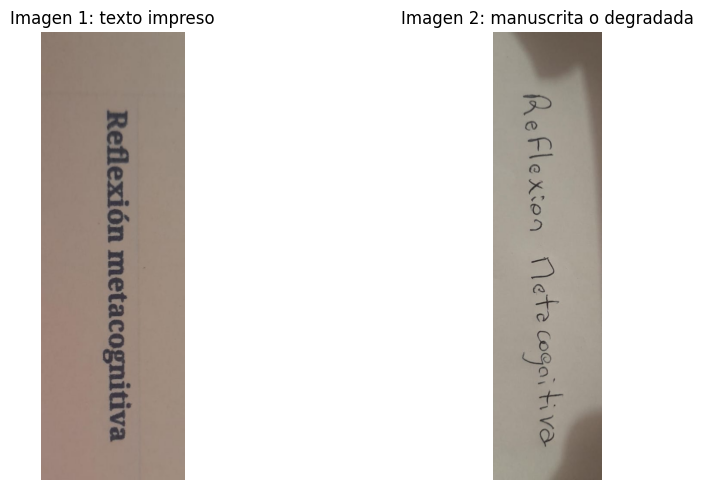

In [ ]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(imagen_impresa)
ejes[0].set_title("Imagen 1: texto impreso")
ejes[0].axis("off")

ejes[1].imshow(imagen_mano)
ejes[1].set_title("Imagen 2: manuscrita o degradada")
ejes[1].axis("off")

plt.tight_layout()
plt.show()

### Registro opcional de consulta a un LLM

Si le pidieron ayuda a un LLM para escribir o corregir código, dejen trazabilidad aquí:

* **Consulta exacta que realizaron:**
* **Respuesta resumida del LLM:**
* **Qué parte decidieron aceptar:**
* **Qué parte decidieron verificar antes de ejecutar:**
* **Qué fuente usaron para validar:**

In [ ]:
print("✦ Ejecutando OCR sobre la imagen impresa...")

imagen_impresa_rgb = imagen_impresa.convert("RGB")
pixel_values = processor(images=imagen_impresa_rgb, return_tensors="pt").pixel_values

with torch.no_grad():
    generated_ids = model.generate(pixel_values)

texto_impresa = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("✓ Texto reconocido en la imagen impresa:")
print(texto_impresa)

✦ Ejecutando OCR sobre la imagen impresa...


c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\transformers\generation\utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


✓ Texto reconocido en la imagen impresa:
RECEIPTATION ORDER


In [ ]:
print("✦ Ejecutando OCR sobre la imagen a mano...")

imagen_mano_rgb = imagen_mano.convert("RGB")
pixel_values = processor(images=imagen_mano_rgb, return_tensors="pt").pixel_values

with torch.no_grad():
    generated_ids = model.generate(pixel_values)

texto_mano = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("✓ Texto reconocido en la imagen manuscrita:")
print(texto_mano)

✦ Ejecutando OCR sobre la imagen a mano...
✓ Texto reconocido en la imagen manuscrita:
RECEIPT NO.U. MODE FLAV


### Registro comparativo de resultados

Completen una tabla comparativa con estos campos:

| Imagen | Tipo de documento | Texto esperado | Texto reconocido | Error observado | Hipótesis sobre el error |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Imagen 1 | [Completar] | [Completar] | [Completar] | [Completar] | [Completar] |
| Imagen 2 | [Completar] | [Completar] | [Completar] | [Completar] | [Completar] |

### Extensión optativa: medición con CER o WER

Si quieren profundizar, comparen el texto reconocido contra un texto de referencia. No hace falta resolver una evaluación exhaustiva, pero sí vale la pena experimentar con una métrica simple para cuantificar diferencias.

Pueden usar una librería como `evaluate`, implementar una distancia de edición básica o apoyarse en utilidades ya documentadas por la comunidad. Si toman esta ruta, registren también la fuente que usaron para entender la métrica.

## Consigna de Lectura e Interpretación

1. ¿El modelo respondió mejor al texto impreso o al manuscrito?
2. ¿Qué tipo de error apareció con mayor frecuencia: omisión, sustitución, segmentación o ruido?
3. ¿La limitación que observaron parece venir del modelo, de la calidad de la imagen o de la tarea elegida?
4. Si mañana tuvieran que implementar OCR en un desarrollo real, ¿usarían este mismo enfoque sin cambios? ¿Qué revisarían antes?

## Movimiento 3 - ¿Qué aprendí sobre cómo aprender?

**Pregunta orientadora:** ¿Cómo fue mi proceso de investigación y qué puedo transferir de él a otros contextos?

Este último movimiento es metacognitivo. No se trata solo de evaluar OCR, sino de explicitar cómo investigaron, qué decisiones tomaron y qué hábitos conviene conservar para futuros problemas técnicos.

### Preguntas de reflexión final

Respondan de manera fundamentada:

1. ¿Qué fuentes resultaron más confiables para este tipo de verificación técnica? ¿Por qué?
2. ¿Qué criterios usaron para distinguir información válida de información incorrecta, imprecisa o desactualizada?
3. ¿Qué rol cumplió el LLM en su proceso? ¿En qué momento fue útil y en qué momento se volvió un obstáculo?
4. ¿Qué harían distinto la próxima vez que investiguen un tema técnico nuevo?
5. ¿Qué aprendieron sobre investigación técnica que puedan transferir a otros desarrollos fuera de OCR?

## Cierre del laboratorio

En este cuaderno no buscamos solamente que un modelo lea texto desde una imagen. Buscamos, sobre todo, que ustedes practiquen una forma de trabajo más rigurosa frente a la abundancia de información técnica disponible.

Una parte importante de la formación actual en IA no consiste en memorizar herramientas, sino en desarrollar criterio para investigar, verificar y decidir. Si este cuaderno funcionó bien, entonces no solo aprendieron algo sobre OCR: también fortalecieron una metodología de trabajo transferible a cualquier tecnología nueva que aparezca en su recorrido profesional.

## Rúbrica de evaluación

| Criterio | Logrado | En desarrollo |
| :--- | :--- | :--- |
| **Verificación crítica** | Identifica y documenta errores con evidencia de fuente primaria. Distingue entre incorrecto, impreciso y desactualizado. | Identifica algunos errores pero sin evidencia de fuente primaria, o no distingue entre tipos de error. |
| **Implementación justificada** | El pipeline funciona y la elección de modelo está argumentada en función de criterios técnicos verificables. | El pipeline funciona pero la elección de modelo no está justificada o se apoya solo en el texto original no verificado. |
| **Reflexión metacognitiva** | La reflexión final articula aprendizajes transferibles sobre el proceso de investigación, no solo sobre OCR. | La reflexión existe pero se limita a describir lo que se hizo sin extraer aprendizajes sobre el proceso. |